# Visualización de Series de Tiempo Continuas (Múltiples Muestras MIDI)

**Finalidad del Notebook:**  
A diferencia del análisis individual, el objetivo de este notebook es explorar cómo se comportan múltiples secuencias musicales cuando son concatenadas. Aquí desarrollaremos una lógica para extraer los eventos de tiempo y *pitch* de varios archivos MIDI y **unirlos en una única serie de tiempo continua**. Esto nos permite observar patrones, que tan densas son las notas a lo largo del tiempo y preparar los datos para análisis secuenciales más complejos donde el contexto histórico abarque múltiples piezas.

### Importación de Librerías
Comenzamos cargando las herramientas fundamentales para nuestro entorno de trabajo:
* `os` y `glob`: Para la manipulación de rutas y lectura masiva de directorios.
* `mido`: Para el procesamiento especializado de los objetos MIDI y sus mensajes (*meta-mensajes, note_on, note_off*).
* `pandas` y `numpy`: Para futuras operaciones vectoriales y estructuración de los datos extraídos.
* `matplotlib.pyplot` y `seaborn`: Para la creación del entorno gráfico y la renderización de nuestras series de tiempo.


In [1]:
import os
from glob import glob
import random
import mido
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Carga del Dataset (Rutas de Archivos)
Definimos la ruta principal donde reside nuestro conjunto de datos (`maestro-v3.0.0`). Utilizando la función `glob` con el parámetro `recursive=True`, recorremos todos los subdirectorios para extraer las rutas absolutas de cada archivo con extensión `.midi` o `.mid`. Estos *paths* se almacenan en la lista `archivos` para su posterior procesamiento.

In [2]:
ruta_base = '../maestro-v3.0.0'
archivos = glob(os.path.join(ruta_base, '**/*.midi*'), recursive=True)

### Construcción de la Función de Concatenación y Visualización
La función `visualizar_serie_continua` está diseñada para iterar sobre una lista de archivos y fusionarlos en un único plano bidimensional:

1. **Variables acumuladoras:** Se inicializa `tiempo_acumulado` en 0. Esta variable en lugar de reiniciar el tiempo en cada canción, sigue sumando el tiempo del archivo anterior.
2. **Extracción de eventos:** Por cada archivo, se iteran sus mensajes. Si el mensaje es de tipo `note_on` y su velocidad (*volumen*) es mayor a 0, se registra la nota en el eje $Y$ y el tiempo acumulado en el eje $X$.
3. **Separación artificial:** Al finalizar de procesar cada canción, se suma arbitrariamente un valor fijo (`tiempo_acumulado += 10`). Esto actúa como una barrera que nos ayuda a distinguir dónde termina una pieza y comienza la siguiente en la gráfica.
4. **Renderización:** Se levanta una figura alargada (`20x6`) usando `matplotlib`. Se utiliza una combinación de `plt.plot()` con alta transparencia para mostrar la conectividad temporal, y `plt.scatter()` para resaltar los golpes exactos de las notas.


In [ ]:
def visualizar_serie_continua(lista_archivos):
    tiempo_acumulado = 0
    eje_x = []
    eje_y = []
    
    for ruta in lista_archivos:
        mid = mido.MidiFile(ruta)
        for msg in mid:
            tiempo_acumulado += msg.time
            if msg.type == 'note_on' and msg.velocity > 0:
                eje_x.append(tiempo_acumulado)
                eje_y.append(msg.note)
        
        tiempo_acumulado += 10 

    plt.figure(figsize=(20, 6))
    plt.plot(eje_x, eje_y, color='teal', linewidth=0.5, alpha=0.8)
    plt.scatter(eje_x, eje_y, s=1, color='black', alpha=0.3)
    
    plt.title(f"Serie de Tiempo Unificada ({len(lista_archivos)} archivos)")
    plt.xlabel("Tiempo total (segundos)")
    plt.ylabel("Pitch (Nota)")
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

### Pruebas de Concatenación (10 Muestras)
Al pasar este subconjunto a nuestra función, generamos una única figura panorámica que representa la evolución continua de las 10 piezas estructuradas una tras otra.

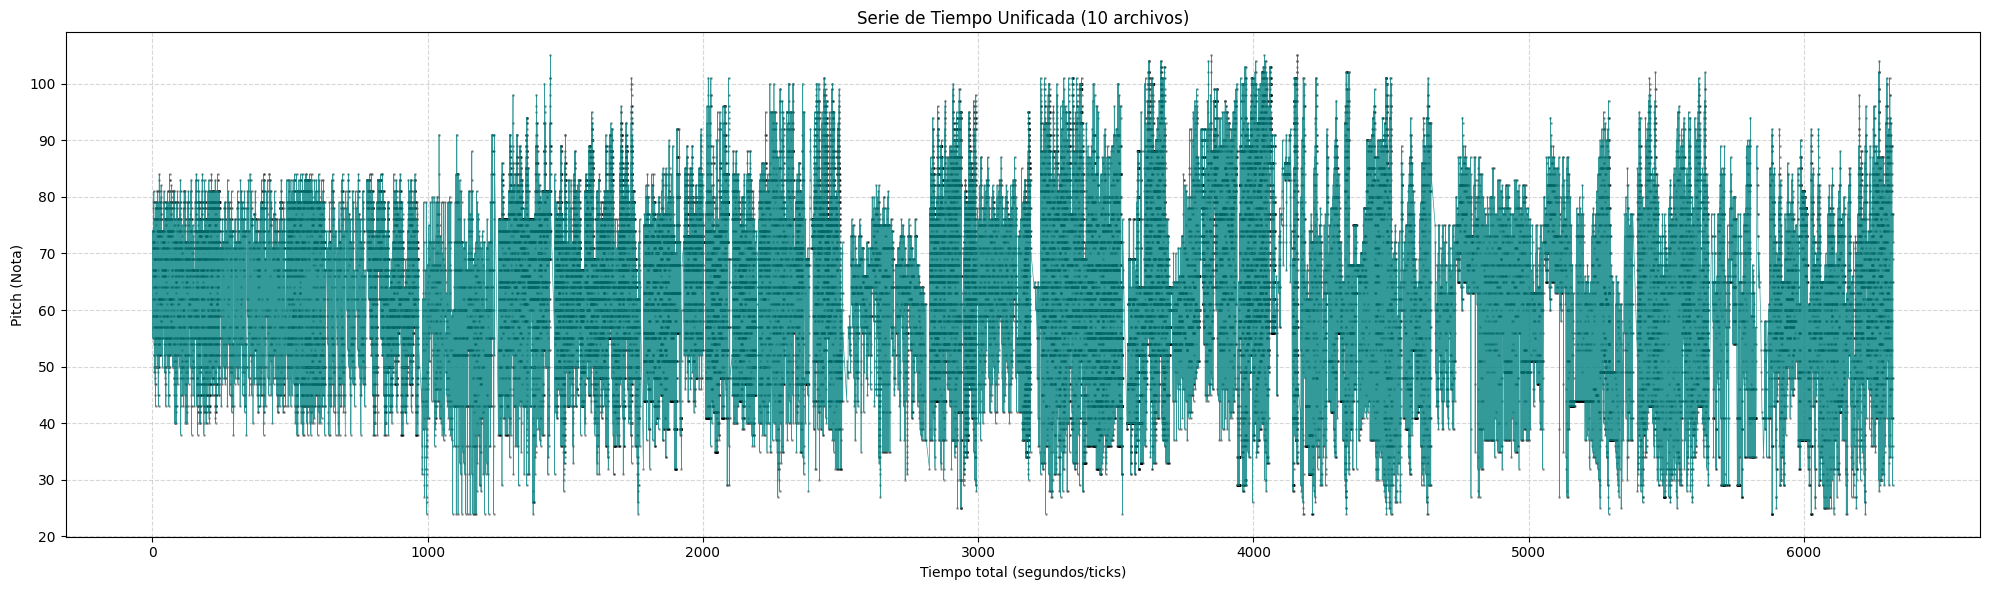

In [15]:
primeras_10_muestras = archivos[:10]
visualizar_serie_continua(primeras_10_muestras)